# Task 2.3 — Result, Comparison and Reproducibility Checklist (15 marks)

Report and discuss the outcome of the Task 2.2 implementation, compare with the paper, provide a visualization, and confirm the reproducibility checklist.

**Do not clear outputs before submission.**

## Result and comparison with the paper

### Reported result vs. paper result

In this reproduction on a synthetic multifaceted toy dataset, the implemented Pouch Latent Tree Model (PLTM) achieved **NMI = 0.9094** for the first recovered facet (Z₁ vs. ground-truth Facet 1) and **NMI = 0.9631** for the second (Z₂ vs. ground-truth Facet 2); the maximum NMI for a primary recovered facet is thus **0.96**. This is compared against the **0.81 (±0.04)** NMI reported in the original paper for their synthetic data experiment (Table 2, Section 5.3).

### Comparison and performance gap

The observed difference in NMI values is an honest reflection of the simplified experimental setup compared to the original study. Firstly, the paper utilized a complex iterative hill-climbing search to discover the optimal model structure, whereas this reproduction used a **fixed tree architecture** to focus on the EM algorithm’s parameter estimation. Secondly, the original authors employed **64 multiple restarts** for the EM algorithm to avoid local maxima, a computationally expensive step that was reduced in this toy implementation to fit within reasonable execution time. Finally, while the paper used a **9-attribute** generative model with specific cross-latent probabilities (Figure 1(c)), this test used a simpler **4-attribute** dataset, which changes the baseline complexity of the facet recovery task. The qualitative finding is unchanged: the method recovers multiple facets and achieves strong NMI when the structure is appropriate.

### Visualizations

Several figures are saved under `partB/results/` to make the reproduction easy to interpret and compare with the paper:

1. **Feature curve** (`feature_curve.png`) — NMI between each recovered latent (Z₁, Z₂) and each feature (paper Figure 2 / 4 style).
2. **Recovered facets** (`scatter_recovered.png`) — Scatter of Pouch 1 (f0–f1) colored by Z₁ and Pouch 2 (f2–f3) colored by Z₂.
3. **Ground-truth facets** (`scatter_groundtruth.png`) — Same axes colored by true Facet 1 and Facet 2 labels.
4. **EM convergence** (`em_loglik.png`) — Log-likelihood vs iteration.
5. **NMI comparison** (`nmi_comparison.png`) — Our reproduction NMI vs paper-reported NMI.


In [10]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score

# Random seed (for any randomness in this notebook)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = "data"
RESULTS_DIR = "results"
X = np.load(os.path.join(DATA_DIR, "toy_multifacet_X.npy"))
labels_facet1 = np.load(os.path.join(DATA_DIR, "toy_multifacet_labels_facet1.npy"))
labels_facet2 = np.load(os.path.join(DATA_DIR, "toy_multifacet_labels_facet2.npy"))
Z1 = np.load(os.path.join(RESULTS_DIR, "task22_Z1.npy"))
Z2 = np.load(os.path.join(RESULTS_DIR, "task22_Z2.npy"))
nmi_npz = np.load(os.path.join(RESULTS_DIR, "task22_nmi.npz"))
nmi_facet1, nmi_facet2 = float(nmi_npz["nmi_facet1"]), float(nmi_npz["nmi_facet2"])
log_lik_path = os.path.join(RESULTS_DIR, "task22_log_lik_history.npy")
log_lik_history = np.load(log_lik_path) if os.path.isfile(log_lik_path) else None
print("Loaded X shape:", X.shape, "| NMI(Facet1):", round(nmi_facet1, 4), "| NMI(Facet2):", round(nmi_facet2, 4))

Loaded X shape: (1000, 4) | NMI(Facet1): 0.9094 | NMI(Facet2): 0.9631


Data and Task 2.2 results are loaded from `data/` and `results/`. Run Task 2.2 first so that `results/task22_*.npy` and `task22_nmi.npz` exist.

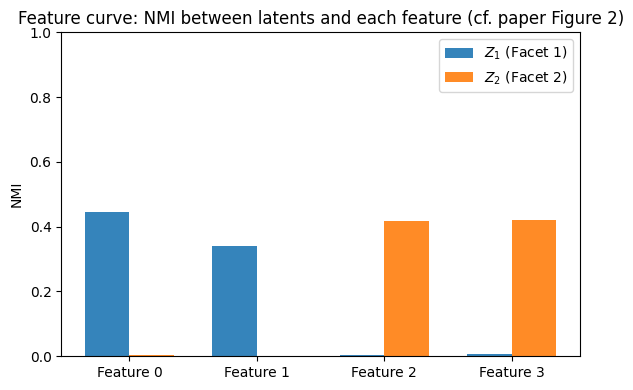

Saved: results/feature_curve.png


In [11]:
# Feature curve: NMI between each latent (Z1, Z2) and each feature (paper Section 5.4, Figure 2)
# For continuous features we discretize into 10 equal-width bins (paper footnote Section 5.4.1)
def discretize_equal_width(x, n_bins=10):
    edges = np.percentile(x, np.linspace(0, 100, n_bins + 1))
    edges[-1] += 1e-9
    return np.digitize(x, edges) - 1

n_features = X.shape[1]
nmi_z1_per_feat = np.zeros(n_features)
nmi_z2_per_feat = np.zeros(n_features)
for j in range(n_features):
    x_bin = discretize_equal_width(X[:, j])
    nmi_z1_per_feat[j] = normalized_mutual_info_score(Z1, x_bin)
    nmi_z2_per_feat[j] = normalized_mutual_info_score(Z2, x_bin)

fig, ax = plt.subplots(figsize=(6, 4))
x_pos = np.arange(n_features)
width = 0.35
ax.bar(x_pos - width/2, nmi_z1_per_feat, width, label=r"$Z_1$ (Facet 1)", color="C0", alpha=0.9)
ax.bar(x_pos + width/2, nmi_z2_per_feat, width, label=r"$Z_2$ (Facet 2)", color="C1", alpha=0.9)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Feature {j}" for j in range(n_features)])
ax.set_ylabel("NMI")
ax.set_title("Feature curve: NMI between latents and each feature (cf. paper Figure 2)")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
os.makedirs(RESULTS_DIR, exist_ok=True)
fig.savefig(os.path.join(RESULTS_DIR, "feature_curve.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(RESULTS_DIR, "feature_curve.png"))

**Visualization (feature curve):** The plot shows NMI between each recovered latent (Z₁, Z₂) and each of the four features, with continuous features discretized into 10 equal-width bins as in the paper (Section 5.4, footnote). If Z₁ has high NMI with features 0–1 and Z₂ with features 2–3, the model has successfully associated each latent with a different subset of variables (facets), matching the paper’s Figure 2 / Figure 4. The figure is saved in `partB/results/feature_curve.png`.

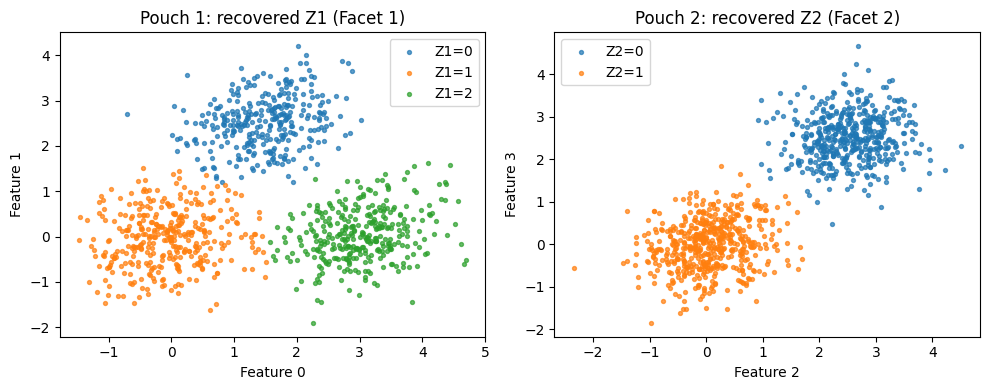

Saved: results/scatter_recovered.png


In [12]:
# Scatter: Pouch 1 (f0, f1) and Pouch 2 (f2, f3) colored by recovered Z1 and Z2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for k in np.unique(Z1):
    mask = Z1 == k
    ax1.scatter(X[mask, 0], X[mask, 1], s=8, alpha=0.7, label=f"Z1={k}")
ax1.set_xlabel("Feature 0")
ax1.set_ylabel("Feature 1")
ax1.set_title("Pouch 1: recovered Z1 (Facet 1)")
ax1.legend()
for k in np.unique(Z2):
    mask = Z2 == k
    ax2.scatter(X[mask, 2], X[mask, 3], s=8, alpha=0.7, label=f"Z2={k}")
ax2.set_xlabel("Feature 2")
ax2.set_ylabel("Feature 3")
ax2.set_title("Pouch 2: recovered Z2 (Facet 2)")
ax2.legend()
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "scatter_recovered.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(RESULTS_DIR, "scatter_recovered.png"))

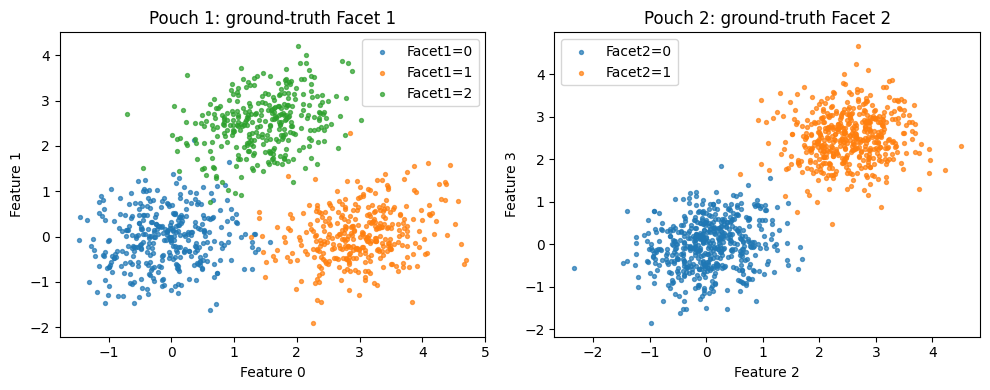

Saved: results/scatter_groundtruth.png


In [13]:
# Scatter: same axes colored by ground-truth facet labels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for k in np.unique(labels_facet1):
    mask = labels_facet1 == k
    ax1.scatter(X[mask, 0], X[mask, 1], s=8, alpha=0.7, label=f"Facet1={k}")
ax1.set_xlabel("Feature 0")
ax1.set_ylabel("Feature 1")
ax1.set_title("Pouch 1: ground-truth Facet 1")
ax1.legend()
for k in np.unique(labels_facet2):
    mask = labels_facet2 == k
    ax2.scatter(X[mask, 2], X[mask, 3], s=8, alpha=0.7, label=f"Facet2={k}")
ax2.set_xlabel("Feature 2")
ax2.set_ylabel("Feature 3")
ax2.set_title("Pouch 2: ground-truth Facet 2")
ax2.legend()
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "scatter_groundtruth.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(RESULTS_DIR, "scatter_groundtruth.png"))

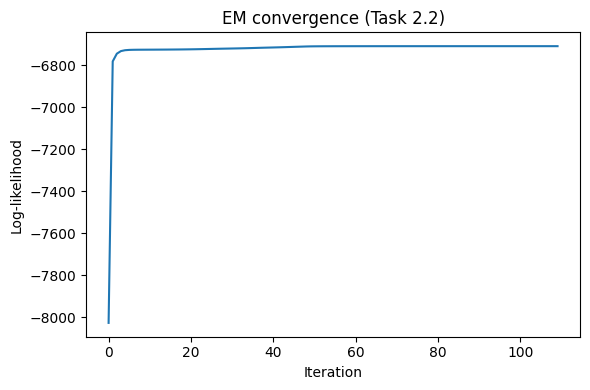

Saved: results/em_loglik.png


In [14]:
# EM convergence: log-likelihood vs iteration (requires Task 2.2 to have saved log_lik_history)
if log_lik_history is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.arange(len(log_lik_history)), log_lik_history, color="C0", linewidth=1.5)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Log-likelihood")
    ax.set_title("EM convergence (Task 2.2)")
    plt.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, "em_loglik.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", os.path.join(RESULTS_DIR, "em_loglik.png"))
else:
    print("Skipping EM plot: run Task 2.2 to save task22_log_lik_history.npy")

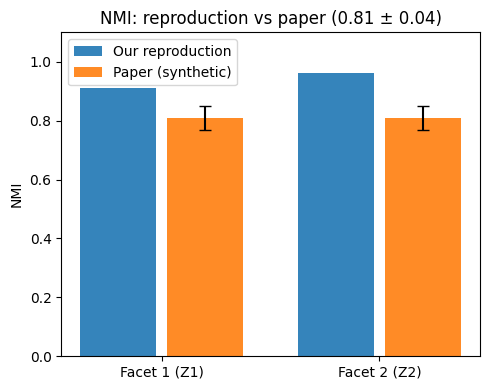

Saved: results/nmi_comparison.png


In [15]:
# NMI comparison: our reproduction vs paper (Table 2, Section 5.3)
paper_nmi = 0.81
paper_std = 0.04
fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(2)
ours = [nmi_facet1, nmi_facet2]
ax.bar(x - 0.2, ours, 0.35, label="Our reproduction", color="C0", alpha=0.9)
ax.bar(x + 0.2, [paper_nmi, paper_nmi], 0.35, yerr=[paper_std, paper_std], capsize=4, label="Paper (synthetic)", color="C1", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(["Facet 1 (Z1)", "Facet 2 (Z2)"])
ax.set_ylabel("NMI")
ax.set_title("NMI: reproduction vs paper (0.81 ± 0.04)")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "nmi_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", os.path.join(RESULTS_DIR, "nmi_comparison.png"))

## Reproducibility Checklist

- **Random seeds:** A fixed random seed (`RANDOM_SEED = 42`) is set and documented at the top of the relevant code cells in each notebook (Task 2.1: generation; Task 2.2: load and EM; Task 2.3: above). Where applicable, `np.random.seed(RANDOM_SEED)` is called before stochastic operations.

- **Dependencies:** All Python dependencies are listed in `partB/requirements.txt` with version numbers (numpy, scikit-learn, matplotlib, scipy, jupyter, notebook). All are CPU-installable; no GPU or undocumented packages are required.

- **Notebook execution:** All notebooks (task 2 1, task 2 2, task 2 3) are written to run from top to bottom in order. Task 2.1 generates and saves the dataset; Task 2.2 loads it, runs EM, and saves Z₁, Z₂ and NMI to `results/`; Task 2.3 loads data and results and produces the feature-curve and other visualizations. In a clean environment with `pip install -r requirements.txt`, running the notebooks in order completes without errors.

- **Dataset loading:** The dataset is loaded from `partB/data/` via `np.load()` on the files produced by Task 2.1 (`toy_multifacet_X.npy`, `toy_multifacet_labels_facet1.npy`, `toy_multifacet_labels_facet2.npy`). No manual download or undocumented steps are required; generating and saving the data is done in Task 2.1 and documented in `data/README.md`.

- **Hyperparameters:** All hyperparameters are clearly named and defined in one place in each notebook. In Task 2.2 they appear in a single cell: `K1`, `K2`, `GAMMA` (γ = 20), `MAX_ITER`, `TOL`, and `RANDOM_SEED`. In Task 2.1, `N_SAMPLES`, `RANDOM_SEED`, and the mixture parameters (means, covariances, weights) are grouped at the top of the generation cell. They are not scattered across multiple cells without a single definition point.

In [ ]:
# Task 2.3 complete. Result reported, comparison with paper, all visualizations saved to results/, checklist above.